In [25]:
import jax
import jax.numpy as jnp
import jax.random as jr
import diffrax
import matplotlib.pyplot as plt
from functools import partial

from diffrax import ControlTerm, MultiTerm, ODETerm

jax.config.update("jax_enable_x64", True)

In [26]:
# ----------------------------
# 1. Define Parameters
# ----------------------------

# Physical Constants and Parameters
omega0 = 5.0          # Natural frequency (rad/s)
omega_d = omega0      # Driving frequency (rad/s), near 2*omega0 for parametric resonance
alpha = .5/omega0**2
# Amplitude of the parametric driving
Q = 20000
b = omega0/Q               # Damping coefficient
mu = 0*.05*1.0              # Nonlinearity coefficient (Duffing term)
k_B = 1.0             # Boltzmann's constant (arbitrary units for simulation)
T = 300.0             # Temperature (K)
D = 0*b * k_B * T       # Noise strength

args_x = (b, mu, omega0, alpha, omega_d)

# Derived Parameters
gamma_eff = b / 2 - alpha / (4 * omega0)  # Effective damping
print(f"gamma_eff: {gamma_eff}")
# delta_omega = omega_d - omega0               # Detuning
# nonlinear_coeff = 3 * mu / (8 * omega0)    # Nonlinear coefficient in amplitude equations

# args_A = (gamma_eff, delta_omega, nonlinear_coeff)

# Simulation Parameters
t0 = 0.0               # Start time
t1 = 20*2*jnp.pi/omega0               # End time
dt0 = 0.001
ts = jnp.linspace(t0, t1, 100000)

# Initial Conditions
x0 = -.1/omega0**2            # Initial displacement
v0 = 0.0               # Initial velocity
y0_x = jnp.array([x0, v0])
A_r0 = x0           # Initial real amplitude
A_i0 = 0.0             # Initial imaginary amplitude
y0_rFrame = jnp.array([A_r0, A_i0])


gamma_eff: -0.000875


In [27]:
# ----------------------------
# 2. Define SDEs
# ----------------------------

def parameteric_driving(t):
    tc = 100.0  # time when amplitude reaches ~99% of max
    ramp = 0.5 * (1 + jnp.tanh(4 * (t - tc/2) / tc))  # smooth transition from 0 to 1
    return (alpha) * ramp * jnp.cos(2*omega_d * t)

# 2.1. Direct Integration SDE for x(t)
def drift_x_fn(t, state, args):
    """
    Drift function for the direct integration of x(t).
    y = [x, v]
    """
    b, mu, omega0, alpha, omega_d = args
    x, v = state
    dxdt = v
    dvdt = -b * v -  (omega0**2 + alpha * jnp.cos(2 * omega_d * t)) * x - mu * x**3
    return jnp.array([dxdt, dvdt])

def diffusion_x_fn(t, state, args):
    """
    Diffusion function for the direct integration of x(t).
    Only the velocity component receives noise.
    """
    return jnp.array([0.0, jnp.sqrt(2 * D)])



In [28]:
# 2.2. Amplitude Equations SDEs for A_r(t) and A_i(t)
def drift_A_fn(t, state, args):
    """
    Drift function for the amplitude equations.
    A = [A_r, A_i]
    """
    b, mu, omega0, alpha, omega_d = args
    A_r, A_i = state
    
    effective_damping_A = -(1j*b*omega0)/(2*1j*omega0+b)
    effective_damping_A_aug = jnp.array([[effective_damping_A.real, -effective_damping_A.imag], [effective_damping_A.imag, effective_damping_A.real]])
    
    effective_damping_Aconj = -alpha/(2*(2*1j*omega0+b))
    effective_damping_Aconj_aug = jnp.array([[effective_damping_Aconj.real, -effective_damping_Aconj.imag], [effective_damping_Aconj.imag, effective_damping_Aconj.real]])
    
    linear_term = effective_damping_A_aug @ jnp.array([A_r, A_i]) + effective_damping_Aconj_aug @ jnp.array([A_r, -A_i])
    
    # Cubic nonlinearity terms
    nonlinear_coeff = -3 * mu /(4*(2*1j*omega0+b))
    nonlinear_coeff_aug = jnp.array([[nonlinear_coeff.real, -nonlinear_coeff.imag],[nonlinear_coeff.imag, nonlinear_coeff.real]])
    
    
    nonlinear_term =  nonlinear_coeff_aug @  jnp.array([A_r, A_i]) * (A_r**2+A_i**2)
 
    # Drift terms
    return linear_term + nonlinear_term

def diffusion_A_fn(t, state, args):
    """
    Diffusion function for the amplitude equations.
    Noise terms for A_r and A_i.
    The scaling of noise is derived based on the relation between x(t) and A(t).
    """
    # The noise in amplitude equations is related to the noise in x(t)
    # Assuming x(t) = A_r * cos(omega_d t) - A_i * sin(omega_d t)
    # The noise terms are scaled by 1/(2 * omega_d)
    sigma_A = jnp.sqrt(D/2) 
    return jnp.array([sigma_A, sigma_A])

In [29]:
N = 2  # (x1, x2)
w_shape = (N,)  # state is (x1, x2, p1, p2)


brownian_motion = diffrax.VirtualBrownianTree(
    t0, t1, 0.0005, w_shape, jr.PRNGKey(0), diffrax.SpaceTimeLevyArea
)

In [30]:

terms_x = MultiTerm(ODETerm(drift_x_fn), ControlTerm(diffusion_x_fn, brownian_motion))
# Define the time points for sampling
saveat = diffrax.SaveAt(ts=ts)
# sample 1000 points
solution_x = diffrax.diffeqsolve(
    terms_x,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_x,
    args=args_x,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
)
sde_samples_x = solution_x.ys[:, :N]


100.00%|##########| [00:00<00:00, 138.16%/s]


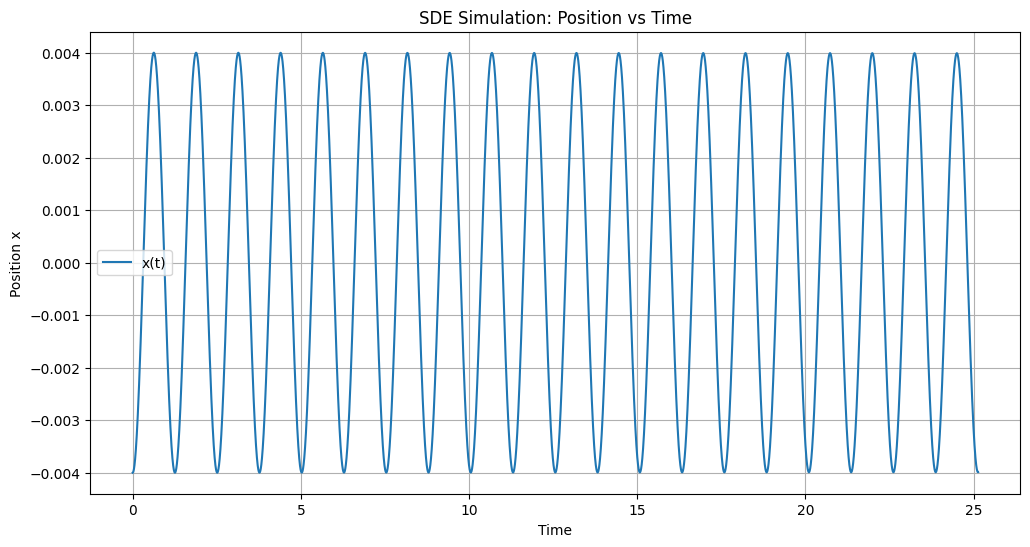

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_x[:, 0], label='x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [32]:
terms_A = MultiTerm(ODETerm(drift_A_fn), ControlTerm(diffusion_A_fn, brownian_motion))
# Define the time points for sampling
# ts = jnp.linspace(t0, t1, 1000)
# saveat = diffrax.SaveAt(ts=ts)
# sample 1000 points
solution_A = diffrax.diffeqsolve(
    terms_A,
    solver=diffrax.SRA1(),
    t0=t0,
    t1=t1,
    dt0=dt0,
    y0=y0_rFrame,
    args=args_x,
    saveat=saveat,
    progress_meter=diffrax.TqdmProgressMeter(),
    max_steps=10000000,
)
sde_samples_A = solution_A.ys[:, :N]


100.00%|##########| [00:00<00:00, 135.99%/s]


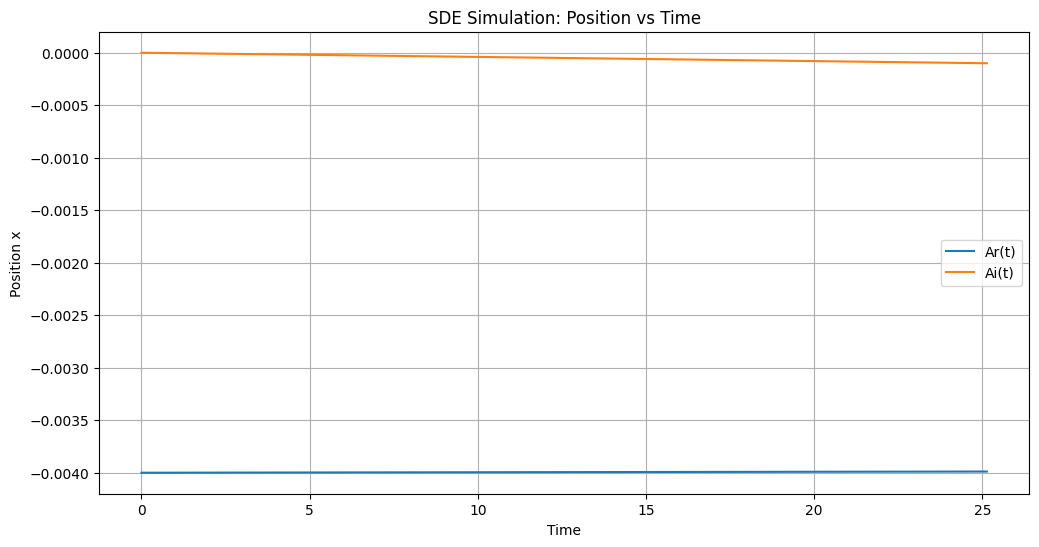

In [33]:
plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_A[:, 0], label='Ar(t)')
plt.plot(ts, sde_samples_A[:, 1], label='Ai(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('SDE Simulation: Position vs Time')
plt.grid(True)
plt.legend()
plt.show()

In [34]:
# def reconstruct_x(t, A_r, A_i):
#     """
#     Reconstruct x(t) from A_r(t) and A_i(t).

#     x(t) = A_r(t) * cos(omega_d t) + A_i(t) * sin(omega_d t)
#     """
#     return A_r * jnp.cos(omega_d * t) + A_i * jnp.sin(omega_d * t)


def reconstruct_x(t, A_r, A_i):
    """
    Reconstruct x(t) from A_r(t) and A_i(t) using complex exponential notation.
    
    x(t) = A(t)exp(iωt) + A*(t)exp(-iωt)
    where A = (A_r + iA_i)/2
    """
    # Construct complex amplitude A = (A_r + iA_i)/2
    A = (A_r + 1j * A_i) / 2
    
    # Compute exp(±iωt) terms
    exp_plus = jnp.exp(1j * omega_d * t)
    exp_minus = jnp.exp(-1j * omega_d * t)
    
    # Return real part of A*exp(iωt) + A**exp(-iωt)
    return jnp.real(A * exp_plus + jnp.conj(A) * exp_minus)



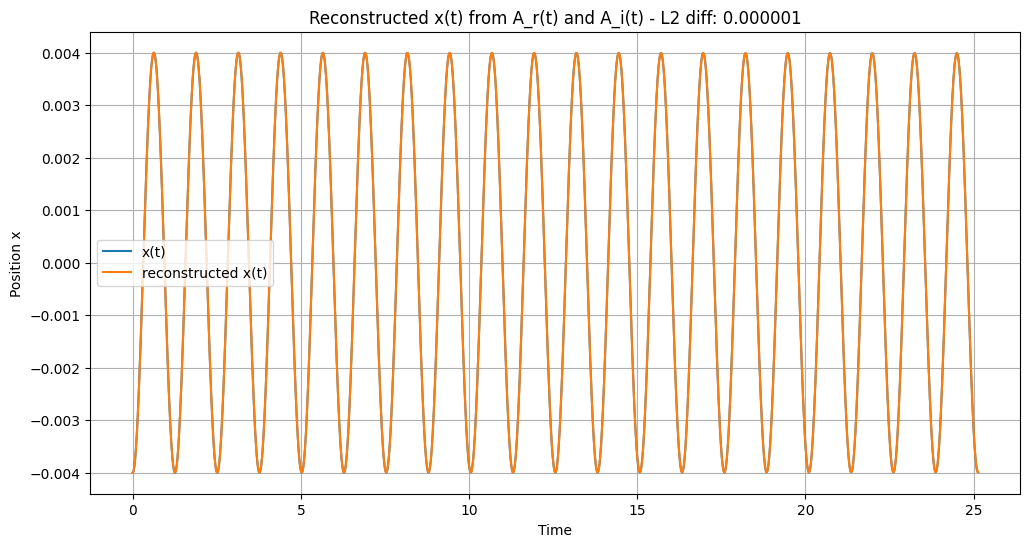

In [35]:
# Calculate L2 difference
l2_diff = jnp.sqrt(jnp.mean((sde_samples_x[:, 0] - reconstruct_x(ts, sde_samples_A[:, 0], sde_samples_A[:, 1]))**2))/jnp.linalg.norm(sde_samples_x[:, 0])

plt.figure(figsize=(12, 6))
plt.plot(ts, sde_samples_x[:, 0], label='x(t)')
plt.plot(ts, reconstruct_x(ts, sde_samples_A[:, 0], sde_samples_A[:, 1]), label='reconstructed x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title(f'Reconstructed x(t) from A_r(t) and A_i(t) - L2 diff: {l2_diff:.6f}')
plt.grid(True)
plt.legend()
plt.show()

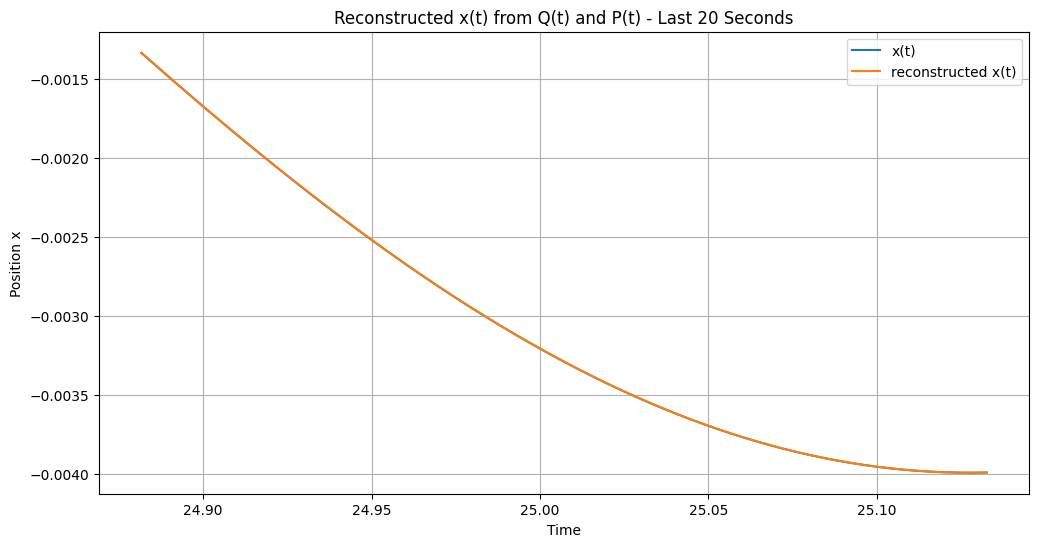

In [36]:
plt.figure(figsize=(12, 6))
plt.plot(ts[-1000:], sde_samples_x[-1000:, 0], label='x(t)')
plt.plot(ts[-1000:], reconstruct_x(ts[-1000:], sde_samples_A[-1000:, 0], sde_samples_A[-1000:, 1]), label='reconstructed x(t)')
plt.xlabel('Time')
plt.ylabel('Position x')
plt.title('Reconstructed x(t) from Q(t) and P(t) - Last 20 Seconds')
plt.grid(True)
plt.legend()
plt.show()